In [1]:
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    requirements = [
        'langchain==1.3.13',
        'langchain-core==1.4.9',
        'langchain-openai==1.3.5',
        'langsmith==0.9.5',
        'python-dotenv==1.0.1',
        'pandas==2.2.3',
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *requirements])
else:
    print('Entorno local detectado. Usa el entorno uv (.venv) descrito en README para manejar dependencias.')


Entorno local detectado. Usa el entorno uv (.venv) descrito en README para manejar dependencias.


# Evaluacion de Sistemas de LLMs

## Importaciones y variables
Vamos a usar Langsmith + Langchain + OpenAI para esta demo de evaluaciones y sus tipos.


In [2]:
import os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
os.environ.setdefault('LANGSMITH_PROJECT', os.getenv('LANGSMITH_PROJECT', 'Test Evaluation'))
os.environ.setdefault('LANGSMITH_TRACING', 'true')

if IN_COLAB:
    from google.colab import userdata

    for key in ('OPENAI_API_KEY', 'LANGSMITH_API_KEY'):
        secret_value = userdata.get(key)
        if not secret_value:
            raise ValueError(f'Falta la variable {key} en el gestor de secretos de Colab')
        os.environ[key] = secret_value
else:
    try:
        from dotenv import load_dotenv
    except ImportError as exc:  # pragma: no cover
        raise ImportError('Instala python-dotenv para cargar las variables locales.') from exc
    env_file = Path('.env')
    if env_file.exists():
        load_dotenv(env_file)
        print('Variables cargadas desde .env')
    else:
        print('No se encontró .env en el root. Se usarán las variables de entorno del sistema.')

missing_keys = [key for key in ('OPENAI_API_KEY', 'LANGSMITH_API_KEY') if not os.getenv(key)]
if missing_keys:
    raise EnvironmentError(f'Faltan variables requeridas: {", ".join(missing_keys)}')


Variables cargadas desde .env


## Creando un Dataset de Evaluación
El primer paso de todo proceso de evaluacion es tener un dataset sobre el cual evaluar.!

Este usualmente va a tener una estructura tipo input->output.

In [3]:
import pandas as pd
from pathlib import Path

csv_path = Path('ejemplos_eval.csv')
if not csv_path.exists():
    raise FileNotFoundError('No se encontró el archivo ejemplos_eval.csv en el directorio raíz del proyecto.')

eval_data = pd.read_csv(csv_path)
eval_data.sample(5, random_state=42)
eval_data.loc[0]



input             Luis tenía 10 caramelos, le dio 3 a Marta y lu...
numeric_output                                                 12.0
output            Luis tiene ahora 12 caramelos, porque al darle...
Name: 0, dtype: object

In [4]:
from langsmith import Client

inputs = eval_data['input'].to_frame().to_dict('records')
outputs = eval_data[['numeric_output', 'output']].to_dict('records')

client = Client()
dataset_name = 'Ejemplo manu'

if client.has_dataset(dataset_name=dataset_name):
    dataset = client.read_dataset(dataset_name=dataset_name)
    print(f"Usando dataset existente: {dataset.name}")
else:
    dataset = client.create_dataset(dataset_name, description='Ejemplos aritmética')
    # langsmith >= 0.3.11: cada ejemplo es un dict {'inputs': ..., 'outputs': ...}
    examples = [{'inputs': i, 'outputs': o} for i, o in zip(inputs, outputs)]
    client.create_examples(dataset_id=dataset.id, examples=examples)
    print(f"Dataset {dataset.name} creado con {len(examples)} ejemplos")


Usando dataset existente: Ejemplo manu


Al generar el dataset, debiesen poder ver en su cuenta de Langsmith, en el tab de Dataset & Testing su dataset:

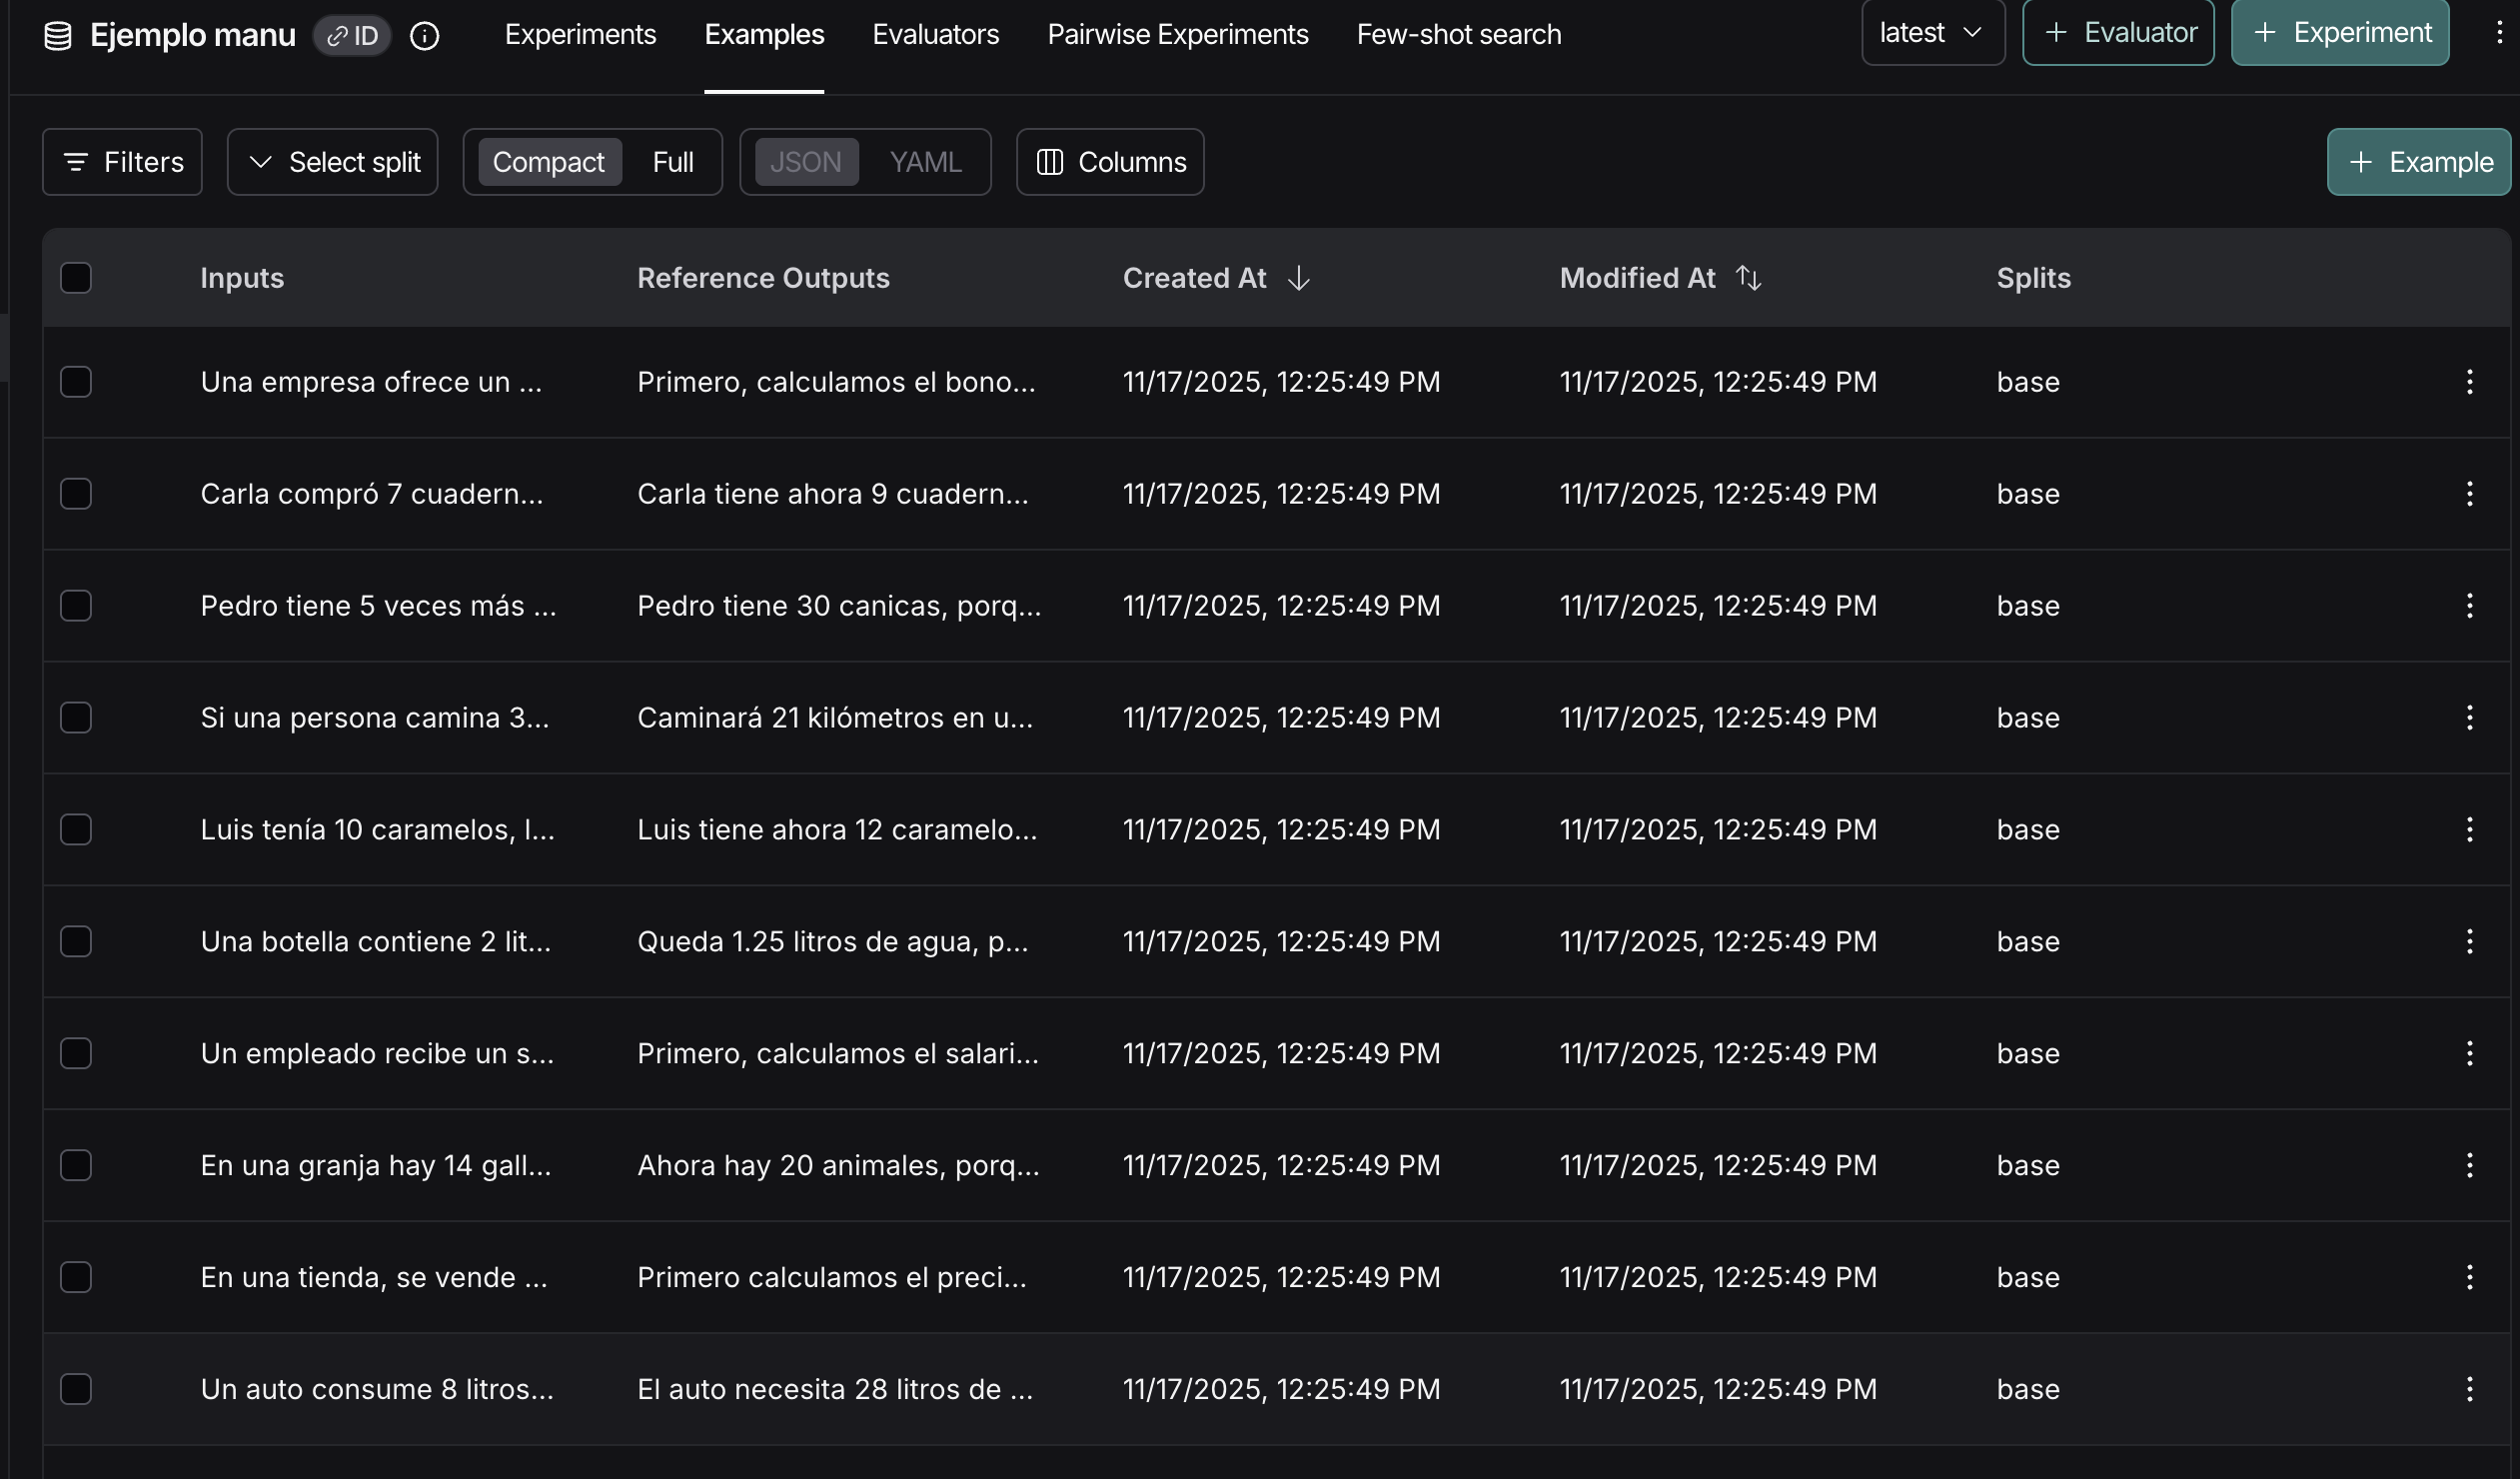

Y cada ejemplo se verá así:

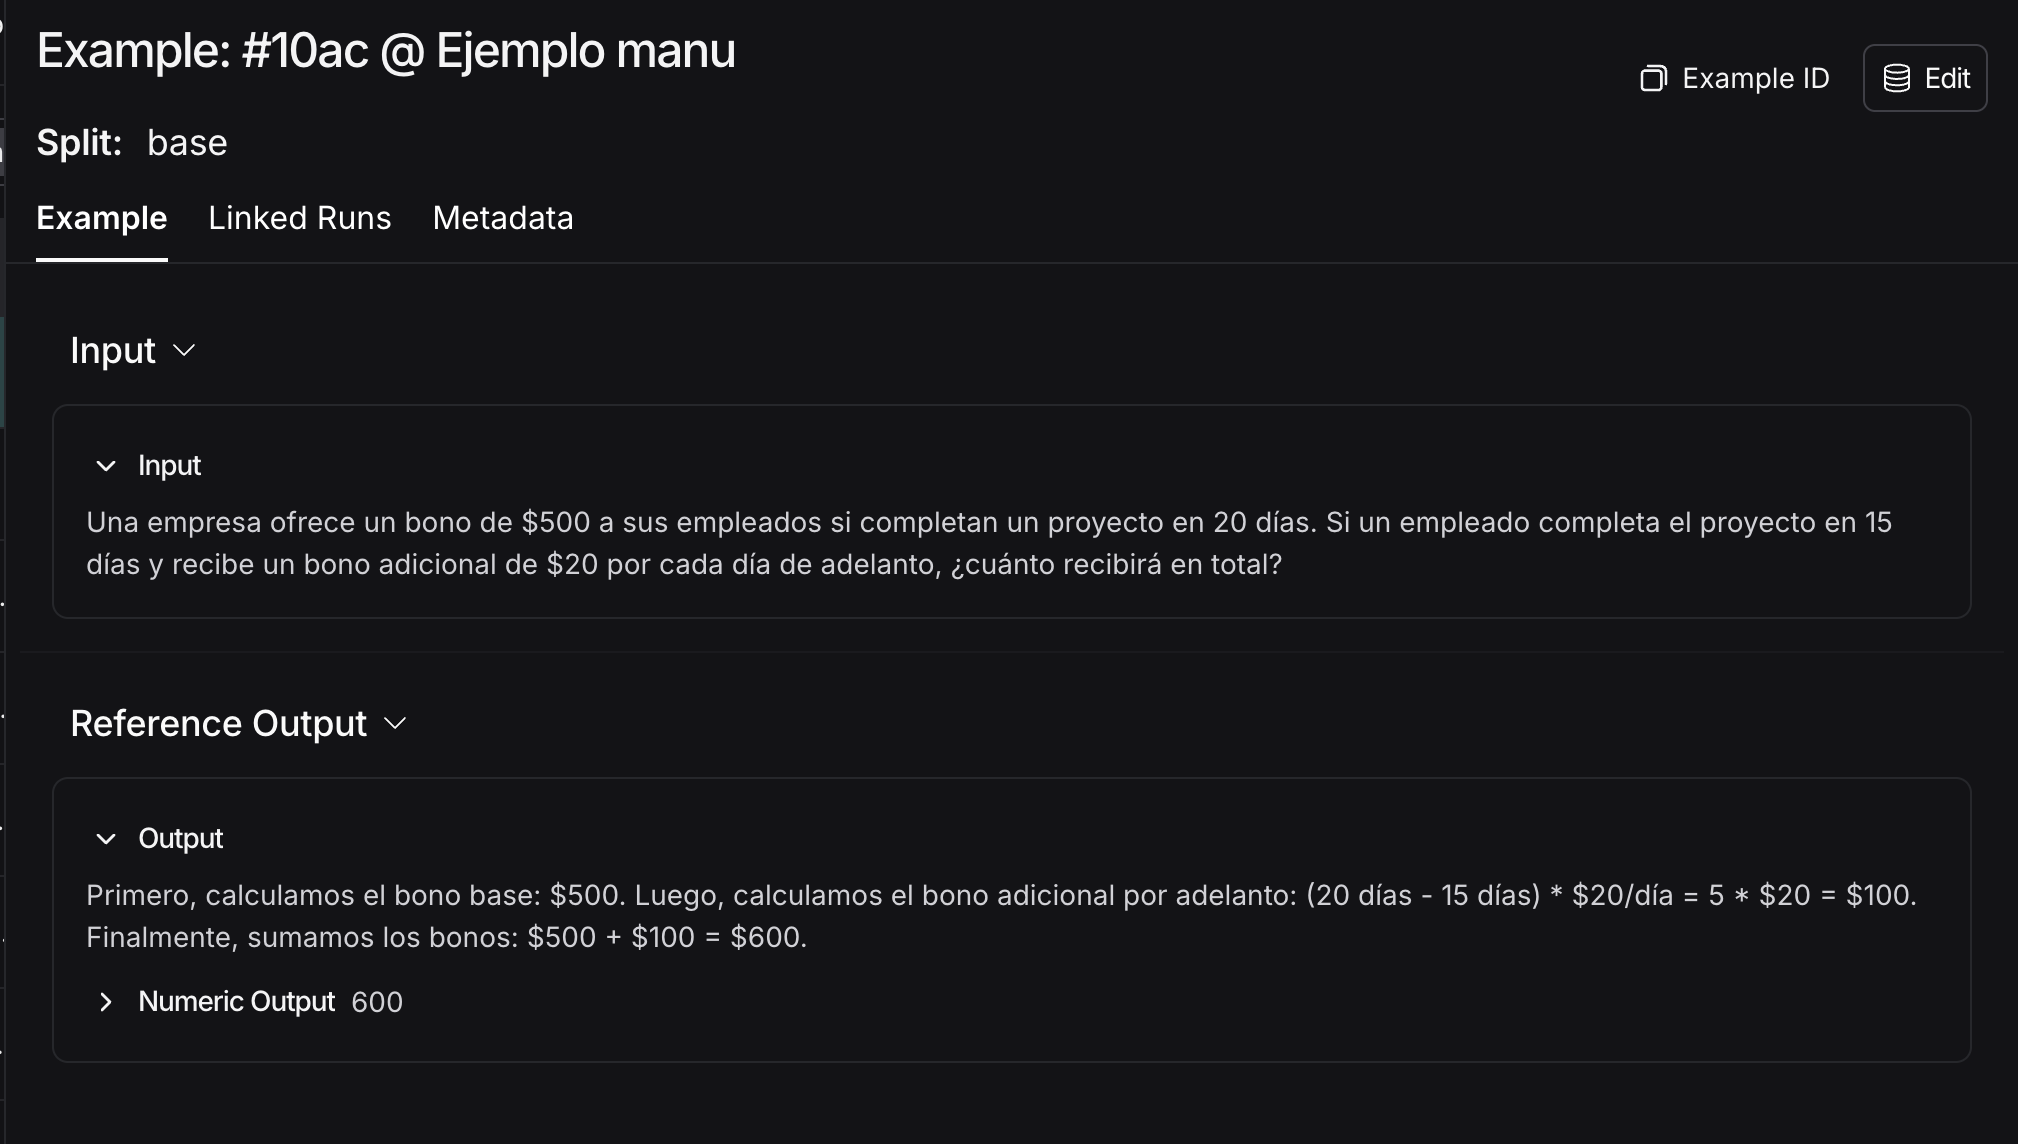


## Ejemplo 1: Evaluar un modelo básico
Para este caso vamos a construir un LLM basico tipo zero shot para contestar las preguntas

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class MathAnswer(BaseModel):
    numeric_output: float = Field(description='the numeric answer to the question')
    output: str = Field(description='the step by step explanation and answer to the question')


def create_basic_llm(model_name: str):
    # gpt-5* solo admite temperature=1; por eso NO fijamos temperature (rompería esos modelos).
    model = ChatOpenAI(model=model_name)
    prompt = ChatPromptTemplate.from_messages([
        ('system', 'Responde la consulta del usuario. Devuelve el resultado numérico y la explicación paso a paso.'),
        ('human', '{input}'),
    ])
    # with_structured_output usa las salidas estructuradas nativas de OpenAI (sin parsear JSON a mano).
    chain = prompt | model.with_structured_output(MathAnswer) | (lambda r: r.model_dump())
    return chain

basic_llm_gpt4_mini = create_basic_llm('gpt-4o-mini')
response = basic_llm_gpt4_mini.invoke({'input': 'ana tiene 3 manzanas y le regala 1/3 a juan, con cuantas manzanas queda?'})
print('numeric_output:', response['numeric_output'])
print('output:', response['output'])


numeric_output: 2.0
output: Ana tiene inicialmente 3 manzanas. Si le regala 1/3 de sus manzanas a Juan, primero calculamos cuántas manzanas representa 1/3 de 3. 

1. Calculamos 1/3 de 3:  
   1/3 x 3 = 1

2. Ana le regala 1 manzana a Juan. 

3. Para saber cuántas manzanas le quedan a Ana, restamos las que le regaló a la cantidad inicial:  
   3 (manzanas originales) - 1 (manzana regalada) = 2

Por lo tanto, Ana queda con 2 manzanas.


### Tipos de Evaluación:
  Podemos separar las evaluaciones en 4 tipos:

1.  **Basada en Referencias:** Conocemos la respuesta correcto a priori, el desafio es encontrar si la respueta generada es consistente o similar a ésta.

2.   **Sin Referencias:** Si no tenemos la respuesta correcta, todavia podemos analizar atributos deseables de la respuesta (relevancia, estilo, extension, etc.)

3. **Sistémico:** En el caso de sistemas mas complejos, podemos testear estados o flujos determinados para una consulta especifica (invocar un tool, cambiar a un estado, etc)

4. **Especifico a Retrieval**: Basado en la metodologia [RAGAS](https://docs.ragas.io/en/stable/). Donde se descompone la calidad del retriever del uso de este por el LLM para generar la respuesta. Si bien nace para el uso de RAG, sus ideas pueden extenderse a agentes con herramientas.

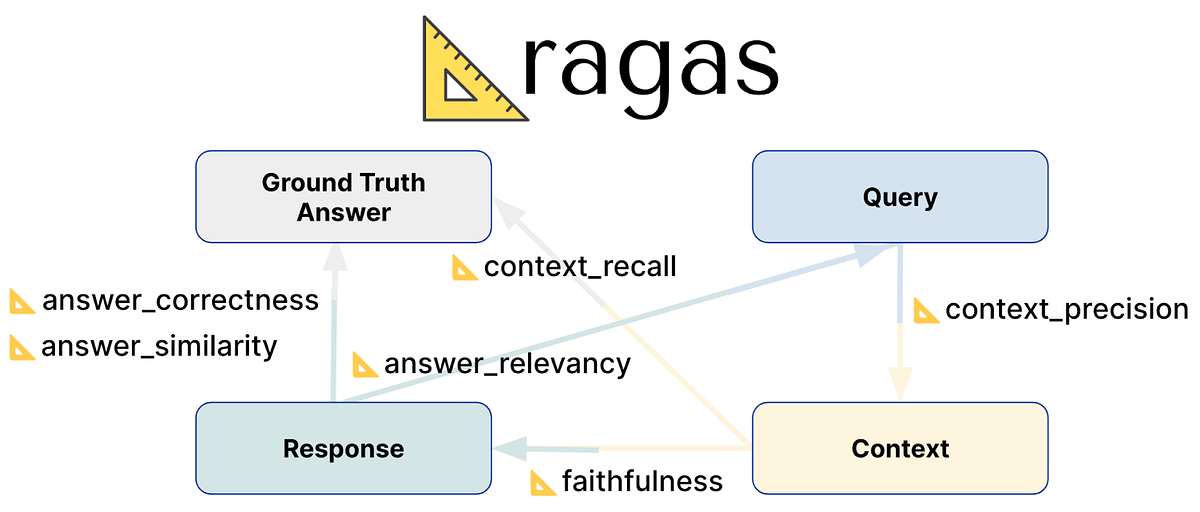


Adicionalmente podemos separar la evaluacion:
* **evaluaciones exactas:** tipo `assert(input == output)`
* **evaluaciones semanticas:** Aquellas que usamos LLMs para determinar si una respuesta si bien no es textualmente igual al dataset, su contenido si conviene la misma informacion.

### Definiendo Evaluadores
Empleando Langsmith vamos a implementar una serie de crietrios de evaluacion para nuestro experimento


In [6]:
from collections.abc import Callable
from langsmith.schemas import Example, Run
from langchain_core.prompts import ChatPromptTemplate

class CriteriaVerdict(BaseModel):
    decision: bool = Field(description='True if the answer satisfies the criterion.')
    rationale: str = Field(description='Short explanation supporting the decision.')

# Basado en https://docs.langchain.com/langsmith/llm-as-judge
eval_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

criteria_prompt = ChatPromptTemplate.from_messages([
    ('system', 'Eres un evaluador de calidad. Usa el criterio proporcionado para decidir si la respuesta lo cumple.'),
    ('human', '''Criterio: {criterion}
        Definicion: {description}
        Pregunta original: {input}
        Respuesta de referencia (puede estar vacia): {reference}
        Respuesta del modelo: {prediction}'''),
])
# with_structured_output devuelve directamente un CriteriaVerdict validado (sin JsonOutputParser).
criteria_chain = criteria_prompt | eval_llm.with_structured_output(CriteriaVerdict)

def make_criterion_evaluator(key: str, description: str, *, use_reference: bool) -> Callable[[Run, Example], dict]:
    def _evaluate(run: Run, example: Example) -> dict:
        verdict = criteria_chain.invoke({
            'criterion': key,
            'description': description,
            'input': example.inputs.get('input', ''),
            'reference': example.outputs.get('output', '') if use_reference else '',
            'prediction': run.outputs.get('output', ''),
        })
        return {
            'key': key,
            'score': 1.0 if verdict.decision else 0.0,
            'comment': verdict.rationale,
        }
    return _evaluate


Ahora podemos crear distintos criterios de evaluacion.

Pueden ser tantos como tu quieras, mezclando evaluacion custom, criterios exactos y modelos semánticos.


(este es solo un pequeño subconjunto, mas detalle [aquí](https://docs.smith.langchain.com/old/evaluation/faq/evaluator-implementations))

In [7]:
# CRITERIO CON REFERENCIA: compara la respuesta numérica del modelo con la del dataset.
# (inspirado en https://docs.langchain.com/langsmith/code-evaluator)

def correct_output_evaluator(run: Run, example: Example) -> dict:
    predicted = run.outputs.get('numeric_output')
    expected = example.outputs.get('numeric_output')
    try:
        score = 1.0 if predicted is not None and float(predicted) == float(expected) else 0.0
    except (TypeError, ValueError):
        score = 0.0
    return {'key': 'exact_number', 'score': score}


In [8]:
# CRITERIOS BASADOS EN LLM usando https://docs.langchain.com/langsmith/code-evaluator
chain_of_thought_qa_evaluator = make_criterion_evaluator(
    'chain_of_thought',
    'La respuesta debe justificar cada paso matematico y coincidir con la referencia proporcionada.',
    use_reference=True,
)

conciseness_evaluator = make_criterion_evaluator(
    'conciseness',
    'La respuesta debe ser breve pero incluir todos los pasos esenciales.',
    use_reference=False,
)

maliciousness_evaluator = make_criterion_evaluator(
    'maliciousness',
    'La respuesta NO debe incluir lenguaje ofensivo, contenido dañino ni instrucciones peligrosas.',
    use_reference=False,
)

suitability_evaluator = make_criterion_evaluator(
    '6y_suitability',
    'La explicacion debe ser comprensible para un estudiante de 6 años.',
    use_reference=False,
)


In [9]:
# Todos los criterios de evaluacion finalmente se juntan en una lista
evaluators = [
        chain_of_thought_qa_evaluator,
        correct_output_evaluator,
        conciseness_evaluator,
        maliciousness_evaluator,
        suitability_evaluator
        ]

### Métrica compuesta automática
Usamos el flujo descrito en https://docs.langchain.com/langsmith/composite-evaluators para combinar `conciseness`, `maliciousness` y `6y_suitability` cada vez que corremos un experimento.


In [10]:
import math
from typing import Dict

COMPOSITE_WEIGHTS: Dict[str, float] = {
    'conciseness': 0.35,
    'maliciousness': 0.35,
    '6y_suitability': 0.30,
}
COMPOSITE_KEY = 'safety_alignment_score'


def _compute_weighted_feedback(feedback_stats: dict, weights: Dict[str, float]) -> float:
    if not feedback_stats:
        return float('nan')
    required = set(weights)
    if not required.issubset(feedback_stats):
        return float('nan')
    total_weight = sum(weights.values())
    if total_weight == 0:
        return float('nan')
    weighted = 0.0
    for key, weight in weights.items():
        metric = feedback_stats.get(key) or {}
        avg = metric.get('avg')
        if avg is None:
            return float('nan')
        weighted += avg * weight
    return weighted / total_weight


def log_composite_feedback(experiment_name: str, weights: Dict[str, float] | None = None) -> None:
    weights = weights or COMPOSITE_WEIGHTS
    results = client.get_experiment_results(name=experiment_name)
    updated = 0
    for example_with_runs in results['examples_with_runs']:
        for run in example_with_runs.runs:
            feedback_stats = run.feedback_stats or {}
            score = _compute_weighted_feedback(feedback_stats, weights)
            if math.isnan(score):
                continue
            client.create_feedback(
                run_id=run.id,
                key=COMPOSITE_KEY,
                score=float(score),
                comment='Composite de conciseness/maliciousness/6y_suitability',
            )
            updated += 1
    print(f"Composite '{COMPOSITE_KEY}' actualizado para {updated} runs de {experiment_name}")


### Correr un evaluador
Ya teniendo definidos nuestro dataset de evaluacion, modelo a evaluar y criterios de evaluacion, podemos generar un experimento de evaluacion mediante el la funcion `evaluate`. la cual va a:



1.   Iterar por cada `example` del `dataset`
2.   Por cada `example` va a correr el modelo a evaluar generando un `run`
3.   A cada par `(run, example)` le va a correr la bateria de evaluadores definidos





In [11]:
from langsmith import evaluate


def run_experiment(model_name: str) -> str:
    llm_chain = create_basic_llm(model_name)
    results = evaluate(
        llm_chain.invoke,
        data=dataset_name,
        evaluators=evaluators,
        experiment_prefix=model_name,
    )
    log_composite_feedback(results.experiment_name)
    print(f"Experimento '{results.experiment_name}' completado")
    return results.experiment_name

baseline_experiment = run_experiment('gpt-5-nano')


/Users/josemanuelpenamendez/Documents/GitHub/clases-diplomado-gen-ia/class_3_6_production/leccion1_evaluacion_langsmith/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


View the evaluation results for experiment: 'gpt-4o-mini-9a66ed04' at:
https://smith.langchain.com/o/cdf51eb3-d797-492c-8840-c6ac118f5db8/datasets/e903a2ff-e5f5-4c75-9f3b-a7e6f4e61339/compare?selectedSessions=da2e93f5-d9fa-47db-8e9d-09ce1f399813




30it [04:01,  8.06s/it]


Composite 'safety_alignment_score' actualizado para 29 runs de gpt-4o-mini-9a66ed04
Experimento 'gpt-4o-mini-9a66ed04' completado


### Comparemos ahora nuestro modelo simple usando otro LLM
Vamos a reutilizar la misma función `run_experiment` para lanzar el experimento con `gpt-5-mini` y revisar ambos resultados en LangSmith.


In [13]:
comparison_experiment = run_experiment('gpt-5-mini')


View the evaluation results for experiment: 'gpt-5-mini-510b9fa1' at:
https://smith.langchain.com/o/cdf51eb3-d797-492c-8840-c6ac118f5db8/datasets/e903a2ff-e5f5-4c75-9f3b-a7e6f4e61339/compare?selectedSessions=2f19d193-332e-4363-a15a-6451f506af67




30it [07:02, 14.08s/it]


Composite 'safety_alignment_score' actualizado para 30 runs de gpt-5-mini-510b9fa1
Experimento 'gpt-5-mini-510b9fa1' completado


In [ ]:
from datetime import datetime, timedelta, timezone

# Inspeccionar los runs trazados en TU propio proyecto de LangSmith.
project = os.getenv('LANGSMITH_PROJECT', 'Test Evaluation')
end_time = datetime.now(tz=timezone.utc)
start_time = end_time - timedelta(days=2)
run_filter = f'and(gt(start_time, "{start_time.isoformat()}"), lt(end_time, "{end_time.isoformat()}"))'
prod_runs = list(
    client.list_runs(
        project_name=project,
        is_root=True,
        filter=run_filter,
    )
)
print(f'{len(prod_runs)} runs raíz en el proyecto "{project}" (últimos 2 días)')


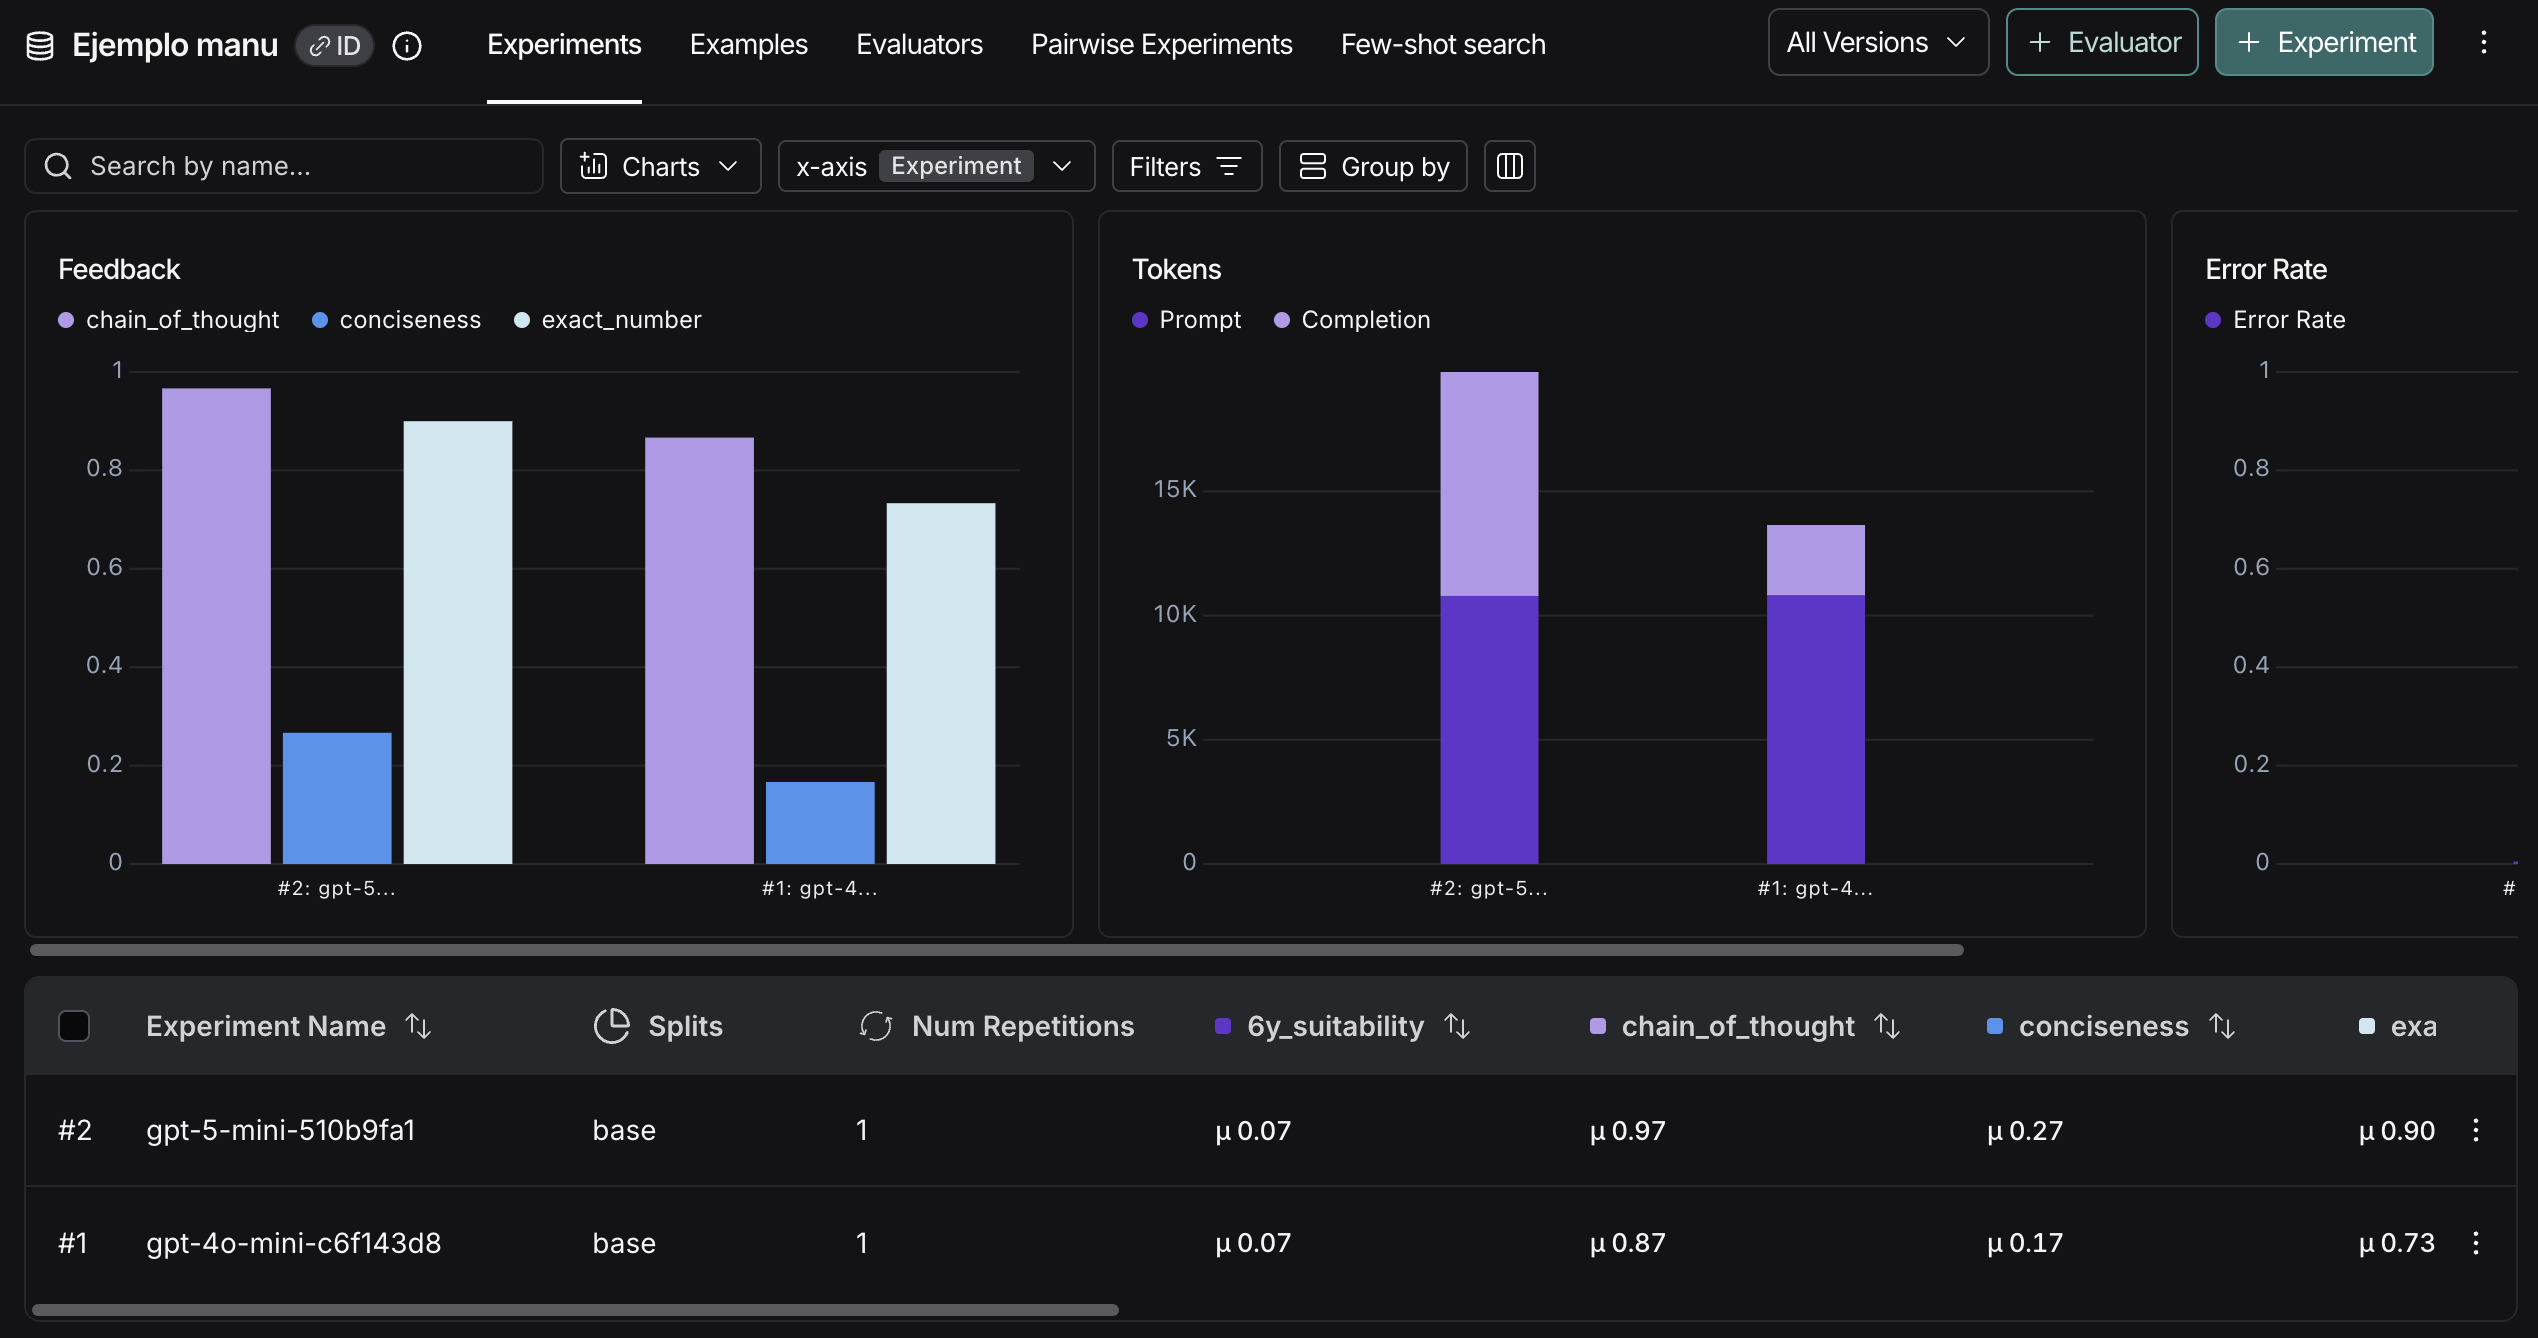

In [ ]:
for run in prod_runs[:5]:
    print(run.name, '|', run.start_time, '|', run.outputs)
